<a href="https://colab.research.google.com/github/shahalam1111/CloudBurstAI-/blob/main/Cloud_Burst_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv("upper_air_sounding.csv")
df["Cloudburst"] = np.where(
    (df["DWPT_C"] > 18) &
    (df["RELH_%"] > 70) &
    (df["THTE_K"] > 330),
    1, 0
)

In [ ]:
# DATA PREPROCESSING
df.fillna(df.mean(), inplace=True)
X = df.drop(columns=["Cloudburst"])
y = df["Cloudburst"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# MODEL IMPLEMENTATION

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)
joblib.dump(model, "cloudburst_model.pkl")

['cloudburst_model.pkl']

In [ ]:
# RESULTS
y_pred = model.predict(X_test)


In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Model Performance")
print("-----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Performance
-----------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00         3

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



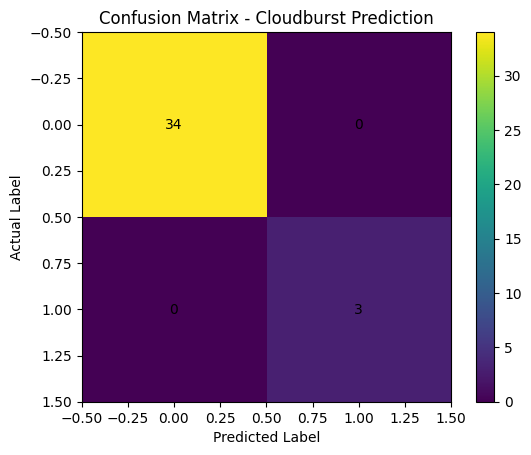

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix - Cloudburst Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [ ]:
# Sample Predictions
sample_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
print("\nSample Predictions:")
print(sample_df)


Sample Predictions:
   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       1          1
9       0          0


In [ ]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": df.drop(columns=["Cloudburst"]).columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("\nFeature Importance:")
print(importance)


Feature Importance:
        Feature  Importance
5      MIXR_gkg    0.262756
2        TEMP_C    0.248207
3        DWPT_C    0.198314
4        RELH_%    0.082935
1        HGHT_m    0.056645
11  Cloud_Burst    0.032775
0      PRES_hPa    0.025634
9        THTE_K    0.022583
6      DRCT_deg    0.022392
8        THTA_K    0.019568
10       THTV_K    0.019340
7     SKNT_knot    0.008850


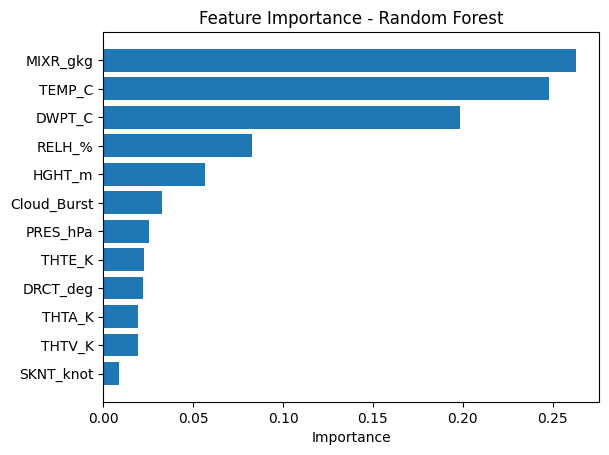

In [ ]:
# Plot Feature Importance
plt.figure()
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np

In [ ]:
#New Dataset
new_data = pd.read_csv("upper_air_sounding_converted.csv")

In [ ]:
# Generate TARGET VARIABLE for new_data

new_data["Cloudburst"] = np.where(
    (new_data["DWPT_C"] > 18) &
    (new_data["RELH_%"] > 70) &
    (new_data["THTE_K"] > 330),
    1, 0
)

In [ ]:
# Split Features & Target
X_new = new_data.drop(columns=["Cloudburst"])
y_true = new_data["Cloudburst"]

In [ ]:
# Loading Trained Scaler & Model
scaler = joblib.load("scaler.pkl")
model = joblib.load("cloudburst_model.pkl")

In [ ]:
#  Apply SAME Preprocessing
X_new_scaled = scaler.transform(X_new)

In [ ]:
# Predictions
y_pred = model.predict(X_new_scaled)

In [ ]:
# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print("Model Performance on New Data")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Model Performance on New Data
--------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



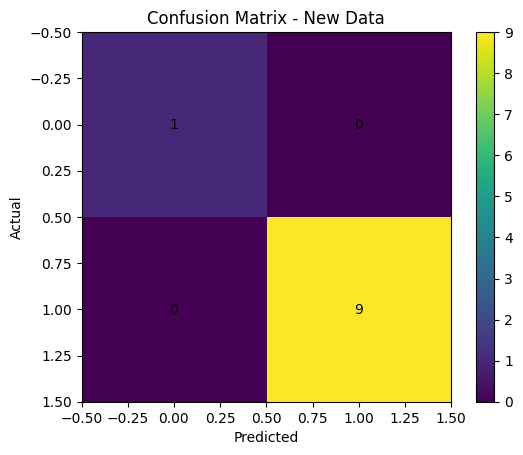

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix - New Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:

#Sample Predictions
results = new_data.copy()
results["Predicted_Cloudburst"] = y_pred
print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   PRES_hPa  HGHT_m  TEMP_C  DWPT_C  RELH_%  MIXR_gkg  DRCT_deg  SKNT_knot  \
0      1006       6    25.4    24.2      93     19.33        45          4   
1      1000      58    25.6    23.9      90     19.09        60          8   
2       964     381    24.0    21.2      84     16.73        60         29   
3       963     390    24.0    21.1      84     16.67        60         29   
4       941     593    23.0    19.4      80     15.31        71         32   
5       925     743    22.0    19.4      85     15.58        80         34   
6       910     885    20.9    19.2      90     15.65        90         34   
7       886    1116    19.2    18.9      98     15.77       103         37   
8       873    1243    18.8    18.2      96     15.29       110         39   
9       850    1473    18.0    16.9      93     14.46       115         36   

   THTA_K  THTE_K  THTV_K  Cloud_Burst  Cloudburst  Predicted_Cloudburst  
0   298.0   354.4   301.5            1       